<a href="https://colab.research.google.com/github/aardaa-1/DI725_Assignment1/blob/main/notebooks/assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Import Train and Test Dataset

In [ ]:
train_df = pd.read_csv("https://raw.githubusercontent.com/aardaa-1/DI725_Assignment1/main/data/train.csv")
test_df = pd.read_csv("https://raw.githubusercontent.com/aardaa-1/DI725_Assignment1/main/data/test.csv")

print(train_df.shape)
print(test_df.shape)


(970, 11)
(30, 11)


In [ ]:
train_df.head()

,issue_area,issue_category,issue_sub_category,issue_category_sub_category,customer_sentiment,product_category,product_sub_category,issue_complexity,agent_experience_level,agent_experience_level_desc,conversation
0,Login and Account,Mobile Number and Email Verification,Verification requirement for mobile number or ...,Mobile Number and Email Verification -> Verifi...,neutral,Appliances,Oven Toaster Grills (OTG),medium,junior,"handles customer inquiries independently, poss...",Agent: Thank you for calling BrownBox Customer...
1,Cancellations and returns,Pickup and Shipping,Reasons for being asked to ship the item,Pickup and Shipping -> Reasons for being asked...,neutral,Electronics,Computer Monitor,less,junior,"handles customer inquiries independently, poss...",Agent: Thank you for calling BrownBox customer...
2,Cancellations and returns,Replacement and Return Process,Inability to click the 'Cancel' button,Replacement and Return Process -> Inability to...,neutral,Appliances,Juicer/Mixer/Grinder,medium,experienced,"confidently handles complex customer issues, e...",Agent: Thank you for calling BrownBox Customer...
3,Login and Account,Login Issues and Error Messages,Error message regarding exceeded attempts to e...,Login Issues and Error Messages -> Error messa...,neutral,Appliances,Water Purifier,less,inexperienced,"may struggle with ambiguous queries, rely on c...","Customer: Hi, I am facing an issue while loggi..."
4,Order,Order Delivery Issues,Delivery not attempted again,Order Delivery Issues -> Delivery not attempte...,negative,Electronics,Bp Monitor,medium,experienced,"confidently handles complex customer issues, e...",Agent: Thank you for contacting BrownBox custo...


In [ ]:
test_df.head()

,issue_area,issue_category,issue_sub_category,issue_category_sub_category,customer_sentiment,product_category,product_sub_category,issue_complexity,agent_experience_level,agent_experience_level_desc,conversation
0,Shopping,Pricing and Discounts,Discounts through exchange offers,Pricing and Discounts -> Discounts through exc...,negative,Appliances,Hand Blender,less,experienced,"confidently handles complex customer issues, e...",Agent: Thank you for calling BrownBox Customer...
1,Login and Account,Account Reactivation and Deactivation,Reactivating an inactive account,Account Reactivation and Deactivation -> React...,negative,Men/Women/Kids,Wrist Watch,medium,junior,"handles customer inquiries independently, poss...",Agent: Thank you for calling BrownBox Customer...
2,Cancellations and returns,Cash on Delivery (CoD) Refunds,Refund timelines for Cash on Delivery returns,Cash on Delivery (CoD) Refunds -> Refund timel...,negative,Appliances,Induction Cooktop,less,junior,"handles customer inquiries independently, poss...",Agent: Thank you for calling BrownBox Customer...
3,Order,Order Delivery Issues,Package shows as delivered but cannot be found,Order Delivery Issues -> Package shows as deli...,negative,Men/Women/Kids,Sunglas,high,junior,"handles customer inquiries independently, poss...",Agent: Thank you for calling BrownBox Customer...
4,Cancellations and returns,Pickup and Shipping,Reimbursement of courier charges for return,Pickup and Shipping -> Reimbursement of courie...,negative,Electronics,Computer Monitor,medium,experienced,"confidently handles complex customer issues, e...",Agent: Thank you for calling BrownBox Customer...


It is seen that in the training dataset we have 970 rows with 11 columns which means there are 970 conversation with 11 features.

We have similar dimensions for test dataset but  much more smaller. There are only 30 conversations.

In [ ]:
print("Null values in the training dataset:")
train_df.isnull().sum()


Null values in the training dataset:


,0
issue_area,0
issue_category,0
issue_sub_category,0
issue_category_sub_category,0
customer_sentiment,0
product_category,0
product_sub_category,0
issue_complexity,0
agent_experience_level,0
agent_experience_level_desc,0


In [ ]:
print("Number of positive,negative, and neutral in the training set:")
train_df['customer_sentiment'].value_counts()



Number of positive,negative, and neutral in the training set:


,count
customer_sentiment,
neutral,542
negative,411
positive,17


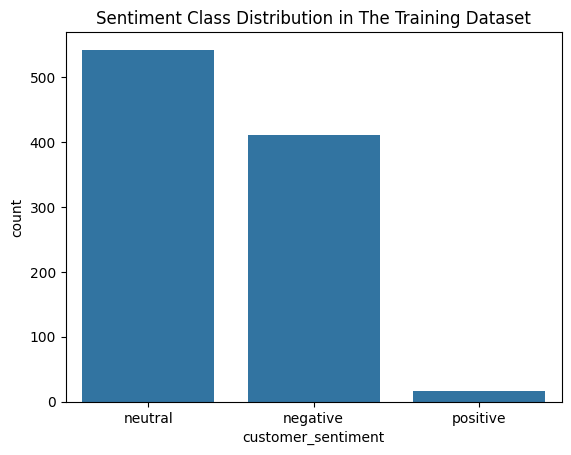

In [ ]:
sns.countplot(x='customer_sentiment', data=train_df)
plt.title("Sentiment Class Distribution in The Training Dataset")
plt.show()

In [ ]:
print("Null values in the test dataset:")
test_df.isnull().sum()


Null values in the test dataset:


,0
issue_area,0
issue_category,0
issue_sub_category,0
issue_category_sub_category,0
customer_sentiment,0
product_category,0
product_sub_category,0
issue_complexity,0
agent_experience_level,0
agent_experience_level_desc,0


In [ ]:
print("Number of positive,negative, and neutral in the test set:")
test_df['customer_sentiment'].value_counts()


Number of positive,negative, and neutral in the test set:


,count
customer_sentiment,
negative,10
neutral,10
positive,10


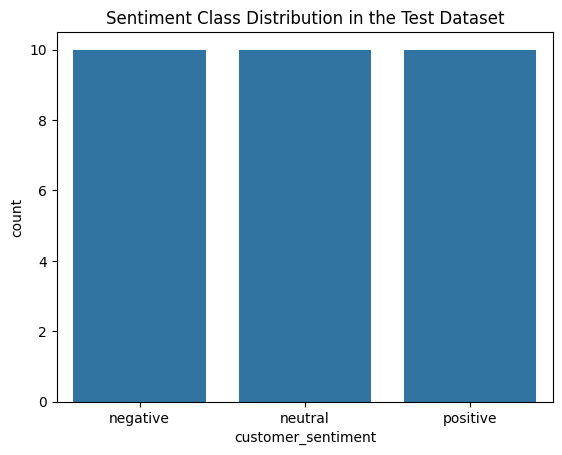

In [ ]:
sns.countplot(x='customer_sentiment', data=test_df)
plt.title("Sentiment Class Distribution in the Test Dataset")
plt.show()

*   issue_area	shows the problem category
*   customer_sentiment shows the	target variables (positive / negative / neutral)
*   conversation shows the full diaologue between customer and agent
*   There are 11 feature for each data set. For the training data set, we have 970 conversations and for the test data set we have 30 conversations.

Initial assessments are done under 4 main headings.


1.   Dataset Size:

The training dataset contains 970 rows and 11 columns which means there 970 conversations. So we can say that the dataset size is relatively small. It is an important factor because small datasets cause an overfitting. Therefore techniques such as validation splitting, regularization and hyperparameter tuning will be important during training.

The test dataset is much smaller than the training dataset with 30 rows. But it is not much important like training dataset, it still allows to assess whether the trained model can generalize to new data.


2.   Missing Value:

The missing value analysis shows that there are no missing values in either the training or the test dataset. All columns in both datasets contain complete data.

This situaiton helps us in the preprocessing stage. Since there are no missing values, we don't need to remove any records. All available features can be directly used during the modeling process.



3.   Target Variable Distribution

The training dataset contains 542 conversations classified as neutral, 411 as negative, and 17 as positive. These numbers indicate a bias towards neutral conversations in the training dataset, meaning it is an imbalanced dataset.

In contrast, the test dataset shows an equal distribution of 30 conversations, with 10 each classified as neutral, negative, and positive. There is no dataset imbalance here.

It means that the model will be traine on imbalanced test set and evaluated on a balanced dataset.

The imbalance in the training dataset may lead the model to favor majority classes during training. Because the positive sentiment class is significantly underrepresented, the model may have difficulty learning meaningful patterns for the positive class.

However, the balanced distribution in the test dataset ensures that model performance can be evaluated fairly across all sentiment categories. It will be easier to observe whether the model struggles with any particular class.

4.   Modeling Considerations

Since the traingng dataset is imbalanced, the simple "accuracy" metric is not going to be enoguh t evaluate it. We need to use other metrics like precision, recall, F1 score and confusion matrices to evaluate the model performance. In addition, class weighting can be used for better understand.

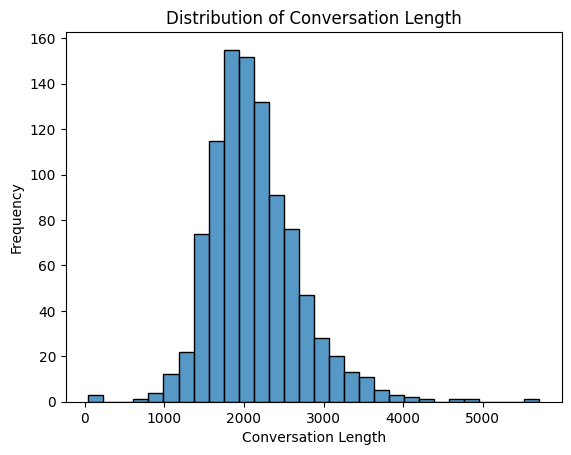

In [ ]:
#conversation length analysis

train_df['conversation_length'] = train_df['conversation'].apply(len)  #calculating conversation lengths
sns.histplot(train_df['conversation_length'], bins=30)
plt.title("Distribution of Conversation Length")
plt.xlabel("Conversation Length")
plt.ylabel("Frequency")
plt.show()

It is seen that the conversation length vary. There are too short and too long answers. The conversation length is important for the tokenization. Before tokenizing inputs (conversations) we need to know the length of the sentences to decide on token limit in the model. If conversations exceed the model’s maximum token length, truncation or other preprocessing strategies may be required.

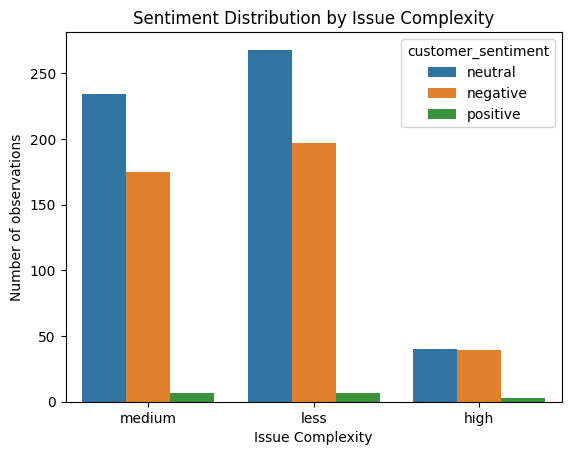

In [ ]:
# we can analyze sentiment vs issue complexity to see if more complex issues lead to negative outcome
sns.countplot(x='issue_complexity', hue='customer_sentiment', data=train_df)  #hue is used to split bars by another category
plt.title("Sentiment Distribution by Issue Complexity")
plt.xlabel("Issue Complexity")
plt.ylabel("Number of observations")
plt.show()

The relationship between customer sentiment and issue complexity also confirm the class imbalance since there are mostly neutral ones occur. Most of the issues in the dataset fall under the medium and less complexity categories. There are a few case for the high complexity.
From this figure it is seen that issue complexity alone may not be the primary factor influencing customer sentiment.

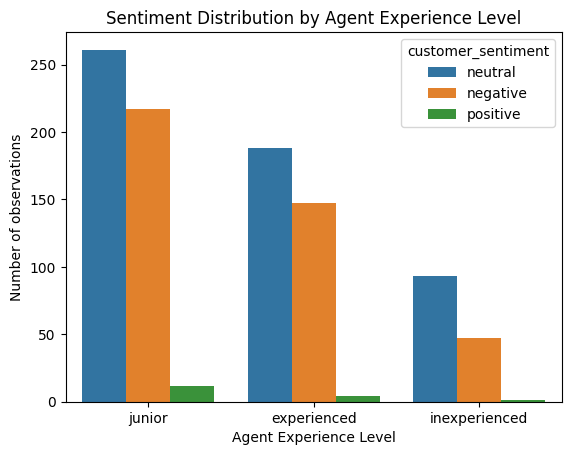

In [ ]:
# similarly, sentiment vs agent experience can be analyzed to check the effect of the experience to the customer sentiment
sns.countplot(x='agent_experience_level', hue='customer_sentiment', data=train_df)  #hue is used to split bars by another category
plt.title("Sentiment Distribution by Agent Experience Level")
plt.xlabel("Agent Experience Level")
plt.ylabel("Number of observations")
plt.show()

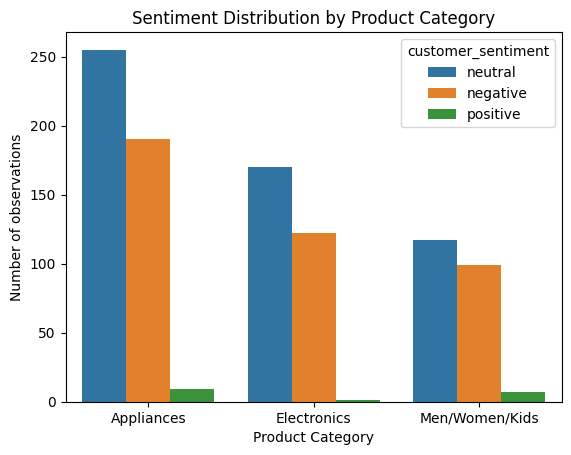

In [ ]:
#We can also analyze the product effect on the customer sentiment
sns.countplot(x='product_category', hue='customer_sentiment', data=train_df)  #hue is used to split bars by another category
plt.title("Sentiment Distribution by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Number of observations")
plt.show()

Factors like issue complexity, agent experience level and product category don't show a strong relationship between customer sentiment. It is again seen that the neutral sentiment dominates the dataset which shows the class imbalance. Therefore the model should focus on this situation in the training and evaluation.

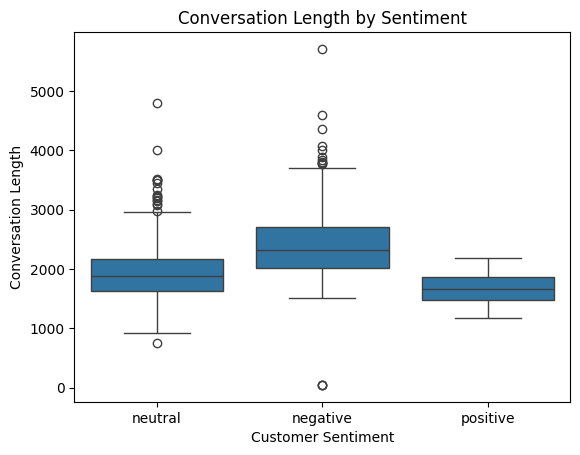

In [ ]:
#Analyzing the relationship between conversation length and customer sentiment
train_df['conversation_length'] = train_df['conversation'].apply(len)
sns.boxplot(x="customer_sentiment", y="conversation_length", data=train_df)

plt.title("Conversation Length by Sentiment")

plt.xlabel("Customer Sentiment")

plt.ylabel("Conversation Length")

plt.show()

From the box plot, the relationship between the conversation length and customer sentiment can be seen. Each box represents the distribution of conversation lengths for the three sentiment categories.

It is seen that negative sentences generally have the longest conversation length. We may understand that the customer experince is getting worse when the conversation becomes longer.The reason may be more complex issues or unresolved problems.

The neutral sentiment conversations show a moderate median conversation length,. These conversation lengths can be classified as average duration.

The shortest conversation lengths are resulted in positive customer sentiments. The reason behind that may be the quick solutions for the problems.

There are also several outliers, particularly within the negative sentiment category. These outliers represent unusually long conversations. The reason may be cases where customers experienced significant difficulties.

As a result, the analysis suggests that longer conversations may be associated with negative customer experiences, while shorter interactions may be linked to more satisfactory outcomes. This result may be useful when interpreting the results of the sentiment classification model.